### explanation 

in this step I want to analyze the scans (after cat12 preprocessing), to create a graph of change in parameters along birth cohorts 
dependent variables: 
1. gray matter volume of different regions

independent variable: 
1. birth years 

constant: 
1. age = 30
2. *range* of age at scan (21-25, 26-30, 31-35 etc.)

covariants: 
1. relevant for age range - age at scan 
2. sex
3. total intracranial volume (tiv)

pseudocode: 
OLS equation 
(predicted y)
gmv_in_roi = b1(bitrh_year)+b2(sex)+b3(tiv)

1. group participants according to age at scan
2. for a single age-at-scan group: 
    a) extract the volumes of ROIs 
    b) calculate the mean of the ROI of the entire group age 
    c) for each birth year, calculate the difference from the average 
3. repeat for all ROIs and parameters 
(4. repeat for all age-at-scan groups, or use a multi SCN)


In [1]:
import statsmodels.formula.api as smf
import pandas as pd          
import matplotlib.pyplot as plt 
import numpy as np

filter by manual classification label

In [2]:
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')
 
print(combined_df.columns)

Index(['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3',
       'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob',
       'gm_volume_cm3', 'protocol', 'source', 'birth_year', 'Unnamed: 0',
       'atlas_name', 'scan_time', 'age_at_scan', 'weight', 'directory_path',
       'estimated_critical_info', 'scan_date', 'file_path',
       'classification_label'],
      dtype='object')


In [3]:
# keep only classification_label=1 and snbb
combined_df = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')]

# remove rows where tiv < 1000 they're outlia
# combined_df = combined_df[combined_df['tiv'] >= 1000]

combined_df['age_in_years'] = pd.to_numeric(combined_df['age_in_years'], errors='coerce')



In [4]:
# calculate the correlation between age_in_years and birth_year
correlation = combined_df['age_in_years'].corr(combined_df['birth_year'])
print(f"Correlation between age and birth year in the entire sample: {correlation}")

# for each age window (25-29, 30-34, 35-39, 40-44)
age_windows = [(20, 24), (25, 29), (30, 34), (35, 39), (40, 44), (45, 49), (50, 54), (55, 59), (60, 64), (65, 69), (70, 74)]
for min_age, max_age in age_windows:
    filtered_df = combined_df[(combined_df['age_in_years'] >= min_age) & (combined_df['age_in_years'] <= max_age)]
    if not filtered_df.empty:
        corr = filtered_df['age_in_years'].corr(filtered_df['birth_year'])
        print(f"Correlation between age and birth year for age window {min_age}-{max_age}: {corr}")
    else:
        print(f"No data for age window {min_age}-{max_age}")

Correlation between age and birth year in the entire sample: -0.9203860749390088
Correlation between age and birth year for age window 20-24: -0.294985391536679
Correlation between age and birth year for age window 25-29: -0.27155981493093523
Correlation between age and birth year for age window 30-34: -0.10312043124869134
Correlation between age and birth year for age window 35-39: -0.1735463131194553
Correlation between age and birth year for age window 40-44: -0.2617106687654025
Correlation between age and birth year for age window 45-49: -0.301914075347936
Correlation between age and birth year for age window 50-54: -0.14252475502313233
Correlation between age and birth year for age window 55-59: -0.25601150417182483
Correlation between age and birth year for age window 60-64: -0.14116379857785175
Correlation between age and birth year for age window 65-69: -0.032324578752708194
Correlation between age and birth year for age window 70-74: 0.10287833057195844


# choose the specific age

In [5]:
min_age = 40
max_age = 45

### Descriptive statistics

In [6]:
# volumes df
volumes = combined_df[(combined_df['age_in_years'] >= min_age) & (combined_df['age_in_years'] < max_age)]

# metadata df
# remove duplicates based on subject_id
metadata = volumes.drop_duplicates(subset=['subject_id'])
print(f"shape of {min_age} - {max_age} years old metadata after removing duplicates: {metadata.shape}")

shape of 40 - 45 years old metadata after removing duplicates: (224, 25)


In [7]:
# type of values in the "age_at_scan" column
print(volumes['age_in_years'].dtype)

float64


In [8]:
# 1. Convert the column to numeric (floats)
volumes['age_in_years'] = pd.to_numeric(volumes['age_in_years'], errors='coerce')

# correlation between age_in_years and birth_year in volumes
correlation = volumes['age_in_years'].corr(volumes['birth_year'])
print(f"Correlation between age_in_years and birth_year: {correlation}")

Correlation between age_in_years and birth_year: -0.2649972614026232


/tmp/ipykernel_571934/1122657970.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volumes['age_in_years'] = pd.to_numeric(volumes['age_in_years'], errors='coerce')


In [9]:
print(f"Columns of metadata: {metadata.columns.tolist()}")
print(f"columns of volumes: {volumes.columns.tolist()}")

Columns of metadata: ['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3', 'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob', 'gm_volume_cm3', 'protocol', 'source', 'birth_year', 'Unnamed: 0', 'atlas_name', 'scan_time', 'age_at_scan', 'weight', 'directory_path', 'estimated_critical_info', 'scan_date', 'file_path', 'classification_label']
columns of volumes: ['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3', 'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob', 'gm_volume_cm3', 'protocol', 'source', 'birth_year', 'Unnamed: 0', 'atlas_name', 'scan_time', 'age_at_scan', 'weight', 'directory_path', 'estimated_critical_info', 'scan_date', 'file_path', 'classification_label']


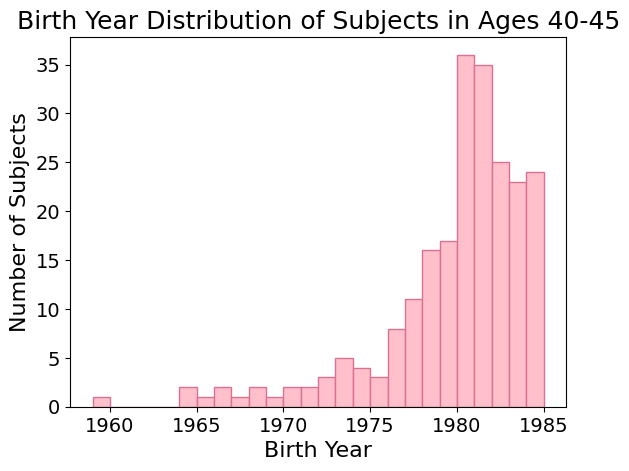

Birth Year Descriptive Statistics:
 Total Subjects: 224
  Minimum: 1959
  Maximum: 1985
  Mean:    1979.38
  SD:      4.31
Sex Distribution: M = 148, F = 76
 min age: 40.0
 max age: 44.99
 mean age: 42.27
 sd age: 1.46


In [10]:
# histogram birth years
plt.hist(metadata['birth_year'], bins=range(metadata['birth_year'].min(), metadata['birth_year'].max() + 1, 1), edgecolor = 'palevioletred',color='pink')
plt.title(f'Birth Year Distribution of Subjects in Ages {min_age}-{max_age}', fontsize=18)
plt.xlabel('Birth Year', fontsize=16)
plt.ylabel('Number of Subjects', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

# Descriptive statistics
min_year = metadata['birth_year'].min()
max_year = metadata['birth_year'].max()
mean_year = metadata['birth_year'].mean()
std_year = metadata['birth_year'].std()

print("Birth Year Descriptive Statistics:")
print(f" Total Subjects: {metadata.shape[0]}")
print(f"  Minimum: {min_year:.0f}")
print(f"  Maximum: {max_year:.0f}")
print(f"  Mean:    {mean_year:.2f}")
print(f"  SD:      {std_year:.2f}")

# Descriptive statistics
print(f"Sex Distribution: M = {(metadata['sex'] == "M").sum() }, F = {(metadata['sex'] == "F").sum() }")
# Age statistics
print(f" min age: {metadata['age_in_years'].min()}")
print(f" max age: {metadata['age_in_years'].max()}")
print(f" mean age: {metadata['age_in_years'].mean():.2f}")
print(f" sd age: {metadata['age_in_years'].std():.2f}")

In [11]:
# # propensity score matching

# # grouping metadata, and then merging the grouping column to volumes
# # # group birth years into quartiles # I don't understand the division here, the group count doesn't make sense
# # metadata["birth_group"] = pd.qcut(metadata["birth_year"], q=5, labels=["Q1_oldest", "Q2", "Q3", "Q4", "Q5_youngest"])
# # print(f"metadata birth group counts:\n{metadata['birth_group'].value_counts()}")

# # # group by birth year ranges
# # bins = [1971, 1976, 1981, 1986, 1991, 1996]  # adjust to your sample range
# # labels = ["[1971–75)", "[1976–80)", "[1981–85)", "[1986–90)", "[1991–95)"]
# # metadata["birth_group"] = pd.cut(metadata["birth_year"], bins=bins, labels=labels, right=False, include_lowest=True)
# # print(f"metadata birth group counts:\n{metadata['birth_group'].value_counts()}")

# # merge birth group back to volumes
# volumes = volumes.merge(metadata[['subject_id', 'birth_group']], on='subject_id', how='left')



In [12]:
# # estimate propensity scores

# import statsmodels.api as sm

# # encode sex as categorical
# volumes["sex"] = volumes["sex"].astype("category")
# sex_dummies = pd.get_dummies(volumes["sex"], drop_first=True)

# # Prepare covariates
# X = pd.concat([sex_dummies, volumes[["tiv"]]], axis=1)
# X = sm.add_constant(X)
# X = X.apply(pd.to_numeric, errors='coerce')
# X["M"] = X["M"].astype(int)


# # Convert birth_group to numeric codes
# volumes["birth_group_code"] = volumes["birth_group"].astype("category").cat.codes
# y = volumes["birth_group_code"]

# volumes.head()
# print(f"columns in volumes before PS calculation: {volumes.columns.tolist()}")
# print(f"birth_group_code value counts:\n{y.value_counts()}")

# print(X.dtypes)

# # Fit multinomial logistic regression
# ps_model = sm.MNLogit(y, X).fit()

# # Predict PS
# ps = ps_model.predict(X)
# ps.columns = [f"ps_group{i}" for i in range(ps.shape[1])]

# # Add PS columns back
# volumes = pd.concat([volumes, ps], axis=1)

# volumes.head()

In [13]:
# # check balance after PS estimation
# def smd(group1, group2):
#     mean_diff = group1.mean() - group2.mean()
#     pooled_sd = np.sqrt((group1.var() + group2.var()) / 2)
#     return abs(mean_diff / pooled_sd)

# for cov in ["tiv"]:
#     g1 = volumes.loc[volumes["birth_group"] == "[1971–75]", cov]
#     g4 = volumes.loc[volumes["birth_group"] == "[1986–90]", cov]
#     print(f"SMD for {cov} (before adjustment):", smd(g1, g4))


# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.kdeplot(data=volumes, x="tiv", hue="birth_group")
# plt.title("TIV distribution across birth groups (before PS adjustment)")
# plt.show()



In [14]:
# # liner model for a specific normalized ROI and a specific age
# # model = smf.ols('normalized_gmv ~ birth_year + sex', data=thirty_years_old).fit()
# model_lin = smf.ols('total_gm_volume ~ birth_year + tiv + sex', data=thirty_years_old.drop_duplicates(subset="subject_code",keep="first")).fit()
# model_quad = smf.ols('total_gm_volume ~ birth_year + I(birth_year**2) + tiv + C(sex) * birth_year', data=thirty_years_old.drop_duplicates(subset="subject_code",keep="first")).fit()

# print(model_quad.compare_f_test(model_lin))

# print(model_quad.summary())

# # shows there's no statistical justification to use quadratic model over linear one


In [15]:
import pandas as pd
import statsmodels.formula.api as smf
from tqdm import tqdm

# create a multiple regression model for each ROI

results = []


# # birth_group
# for roi, df_roi in tqdm(volumes.groupby('region_label')):
#     model = smf.ols('volume_mm3 ~ C(birth_group) + ps_group0 + ps_group1 + ps_group2 + ps_group3 + C(sex) + tiv', data=df_roi).fit() # with propensity score
    
#     # Collect p, t, and coef values
#     for var in model.params.index:
#         results.append({
#             'region_label': roi,
#             'variable': var,
#             'coef': model.params[var],
#             't': model.tvalues[var],
#             'p': model.pvalues[var]
#         })

# Loop over regions (ROI-level analyses)
for roi, df_roi in tqdm(volumes.groupby('region_label')):
    # Fit model with birth_year as a continuous predictor
    model = smf.ols(
        'volume_mm3 ~ birth_year + C(sex) + tiv + age_in_years',
        data=df_roi
    ).fit()
    
    # Collect stats for each variable
    for var in model.params.index:
        results.append({
            'region_label': roi,
            'variable': var,
            'coef': model.params[var],
            't': model.tvalues[var],
            'p': model.pvalues[var]
        })

# # specific roi
# # Fit model with birth_year as a continuous predictor
# roi = 421
# df_roi = volumes[volumes['region_label'] == roi]
# model = smf.ols(
#     'volume_mm3 ~ birth_year + C(sex) + tiv + age_in_years',
#     data=df_roi
# ).fit()

# # Collect stats for each variable
# for var in model.params.index:
#     results.append({
#         'region_label': roi,
#         'variable': var,
#         'coef': model.params[var],
#         't': model.tvalues[var],
#         'p': model.pvalues[var]
#     })





  0%|          | 0/454 [00:00<?, ?it/s]

100%|██████████| 454/454 [00:02<00:00, 184.95it/s]


In [16]:
results_df = pd.DataFrame(results)
print("results_df built:", results_df.shape)
# Example head
print(results_df.head())

# add region name according to the atlas 
atlas_csv = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv")

results_df = results_df.merge(
    atlas_csv[['index', 'name']],     # only keep relevant columns
    how='left',                      # keep all rows from results_df
    left_on='region_label',          # column in results_df
    right_on='index'                 # matching column in atlas_csv
)

# rename and clean up
results_df.rename(columns={'name': 'region_name'}, inplace=True)
results_df.drop(columns='index', inplace=True)

results_df built: (2270, 5)
   region_label      variable          coef          t             p
0             1     Intercept  51894.115814   3.637707  3.307643e-04
1             1   C(sex)[T.M]    -54.101053  -1.869316  6.268593e-02
2             1    birth_year    -25.430146  -3.614988  3.596535e-04
3             1           tiv      1.014028  10.214742  7.367244e-21
4             1  age_in_years    -33.395283  -3.276399  1.192171e-03


In [17]:
# --- Multiple comparison correction (using results_df) ---
from statsmodels.stats.multitest import multipletests

cov_of_interest = 'birth_year'
mask = results_df['variable'] == cov_of_interest
_, fdr_p, _, _ = multipletests(results_df.loc[mask, 'p'], method='fdr_bh')
results_df.loc[mask, 'fdr_p'] = fdr_p

# sort for inspection
results_df = results_df.sort_values(by='fdr_p')
print(results_df.head())


# # --- Multiple comparison correction for birth_group coefficients ---
# from statsmodels.stats.multitest import multipletests

# # Select all birth_group dummy coefficients
# mask = results_df['variable'].str.startswith('C(birth_group)')

# # Extract p-values
# pvals = results_df.loc[mask, 'p']

# # Run FDR correction
# _, fdr_p, _, _ = multipletests(pvals, method='fdr_bh')

# # Assign corrected p-values back
# results_df.loc[mask, 'fdr_p'] = fdr_p

# # Sort for inspection
# results_df = results_df.sort_values(by='fdr_p')
# print(results_df.head())


      region_label    variable        coef         t             p  \
1622           325  birth_year -125.642090 -6.535306  3.257209e-10   
592            119  birth_year  -95.699110 -5.501577  8.894860e-08   
1627           326  birth_year  -76.044287 -5.282247  2.670841e-07   
287             58  birth_year   35.613887  4.582151  7.104129e-06   
2042           409  birth_year   10.635600  4.397453  1.589486e-05   

                         region_name         fdr_p  
1622  7Networks_RH_Limbic_TempPole_1  1.478773e-07  
592   7Networks_LH_Limbic_TempPole_1  2.019133e-05  
1627  7Networks_RH_Limbic_TempPole_2  4.041873e-05  
287           7Networks_LH_SomMot_27  8.063187e-04  
2042                      THA-VPl-rh  1.368343e-03  


In [18]:
# make sure fdr_p is float 
results_df['fdr_p'] = results_df['fdr_p'].astype(float)

# save the rows from results_df where fdr_p < 0.05
significant_results_df = results_df[results_df['fdr_p'] < 0.05].copy()

# increase in volume (t>0)
print(significant_results_df.loc[significant_results_df['t'] > 0, 'region_name'].tolist())

# decrease
print(significant_results_df.loc[significant_results_df['t'] < 0, 'region_name'].tolist())


['7Networks_LH_SomMot_27', 'THA-VPl-rh', 'THA-VPl-lh', 'PUT-VP-lh', 'THA-VPm-lh', 'THA-VPm-rh', 'THA-DP-lh']
['7Networks_RH_Limbic_TempPole_1', '7Networks_LH_Limbic_TempPole_1', '7Networks_RH_Limbic_TempPole_2', '7Networks_RH_Limbic_TempPole_4', '7Networks_LH_Limbic_TempPole_2', '7Networks_LH_Vis_7', '7Networks_RH_Vis_3', '7Networks_LH_Vis_9', '7Networks_LH_Limbic_TempPole_3', '7Networks_LH_Vis_1', '7Networks_RH_Vis_1', '7Networks_LH_Vis_5', '7Networks_LH_Limbic_TempPole_5', '7Networks_LH_Limbic_TempPole_7', '7Networks_LH_Cont_PFCl_3', 'HIP-body-lh', '7Networks_LH_Limbic_TempPole_6']


In [19]:
# significant_results_df.to_csv('/home/gaia/Projects/legacy_data/my_master/significant_rois_late_twenties.csv', index=False)

Mapping 24 significant coefficient values...
Created coefficient map image for visualization.


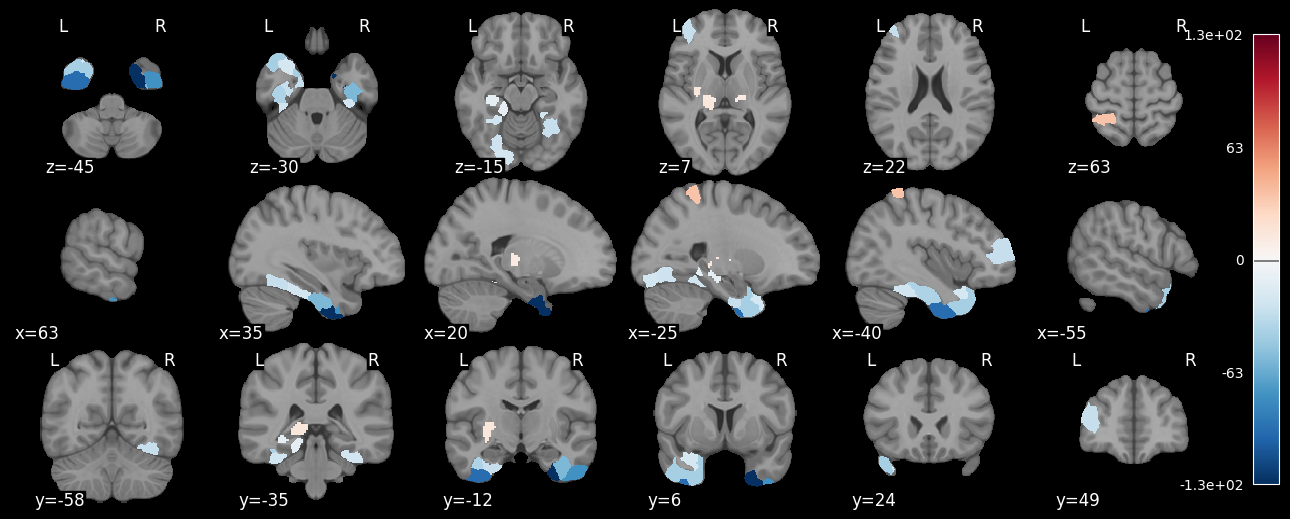

In [20]:
# visualization of significant results on the brain, birth_year

import numpy as np
import nibabel as nib
from nilearn import plotting
from nilearn.image import new_img_like
from nilearn.datasets import load_mni152_template # for background image

# --- 1. Load Your Atlas ---
atlas_file_path = '/media/storage/MATLAB_atlases-20250612T134418Z-1-001/MATLAB_atlases/schaefer2018tian2020_400_7.nii'
atlas_img = nib.load(atlas_file_path)
atlas_labels = atlas_img.get_fdata()


# # --- 2. Extract significant T-values from your results_df ---
# significant_rois_data = results_df[(results_df['variable'] == 'birth_year') & (results_df['fdr_p'] < 0.05)][['region_label', 't']].values.tolist()
# # Create a dictionary for quick lookup of T-values by ROI label
# t_value_map = {label: t_val for label, t_val in significant_rois_data}

# --- 2. Extract significant T-values from your results_df ---
significant_rois_data = results_df[(results_df['variable'] == 'birth_year') & (results_df['fdr_p'] < 0.05)][['region_label', 'coef']].values.tolist()
# Create a dictionary for quick lookup of T-values by ROI label
coef_map = {label: coef for label, coef in significant_rois_data}


# --- 3. Create the full statistical map ---

# 1. Initialize the statistical map array to zeros.
# This ensures that all non-significant ROIs (and the background 0) are set to T=0.
stat_map_data = np.zeros_like(atlas_labels, dtype=float)

# 2. Iterate over the significant ROIs and map their coefficient value.
print(f"Mapping {len(significant_rois_data)} significant coefficient values...")
for label, coef in coef_map.items():
    # Find all voxels in the atlas that match the current ROI label and set their value in the stat_map_data to the coefficient value
    stat_map_data[atlas_labels == label] = coef
# 3. Create the final NIfTI image for visualization.
# This ensures the T-map has the same spatial dimensions and coordinates as your atlas.
t_map_img = new_img_like(atlas_img, stat_map_data)
print("Created coefficient map image for visualization.")

# --- 4. Load background template ---
bg_img = load_mni152_template()

# --- 5. Plot the T-map ---
custom_cut_coords = (6,6,6)

# Plot the T-map using the mosaic display mode
plotting.plot_stat_map(
    stat_map_img=t_map_img,
    bg_img=bg_img,
    # title=f"ROI T-Values",
    cmap='RdBu_r',
    symmetric_cbar=True,
    threshold=1,
    display_mode='mosaic',
    cut_coords=custom_cut_coords,
    colorbar=True
)


# Display the plot
plotting.show()

In [21]:
# print a list of significant regions and their t values
region_list = significant_results_df[['region_name', 't']].values.tolist()

print(f"list of significant regions (birth_year): {region_list}")


list of significant regions (birth_year): [['7Networks_RH_Limbic_TempPole_1', -6.535306288271521], ['7Networks_LH_Limbic_TempPole_1', -5.50157734247094], ['7Networks_RH_Limbic_TempPole_2', -5.282247418776924], ['7Networks_LH_SomMot_27', 4.582150866514536], ['THA-VPl-rh', 4.397453302881647], ['7Networks_RH_Limbic_TempPole_4', -4.367299376051174], ['7Networks_LH_Limbic_TempPole_2', -4.2796184682957055], ['THA-VPl-lh', 4.214133643417228], ['7Networks_LH_Vis_7', -4.184729791487965], ['7Networks_RH_Vis_3', -4.108606949280089], ['7Networks_LH_Vis_9', -3.908414456558631], ['7Networks_LH_Limbic_TempPole_3', -3.72205391015711], ['7Networks_LH_Vis_1', -3.614987704090967], ['7Networks_RH_Vis_1', -3.5780844180894467], ['PUT-VP-lh', 3.5746275760949753], ['7Networks_LH_Vis_5', -3.4427076301875994], ['7Networks_LH_Limbic_TempPole_5', -3.398519092444474], ['THA-VPm-lh', 3.328604281354421], ['7Networks_LH_Limbic_TempPole_7', -3.30049862934513], ['THA-VPm-rh', 3.201658953239972], ['THA-DP-lh', 3.1320233

In [22]:
# # visualization birth_group

# import numpy as np
# import nibabel as nib
# from nilearn import plotting
# from nilearn.image import new_img_like
# from nilearn.datasets import load_mni152_template

# # --- 1. Load Your Atlas ---
# atlas_file_path = '/media/storage/MATLAB_atlases-20250612T134418Z-1-001/MATLAB_atlases/schaefer2018tian2020_400_7.nii'
# atlas_img = nib.load(atlas_file_path)
# atlas_labels = atlas_img.get_fdata()

# # Get all unique ROI labels (excluding 0)
# all_unique_labels = np.unique(atlas_labels)[1:].astype(int)
# print(f"Atlas loaded with shape: {atlas_labels.shape}")
# print(f"Total ROIs in atlas (excluding background): {len(all_unique_labels)}")

# # --- 2. Extract Significant ROIs for birth_group ---
# # Select all dummy-coded birth_group rows that are significant
# mask = results_df['variable'].str.startswith('C(birth_group)') & (results_df['fdr_p'] < 0.05)
# significant_rois_data = results_df.loc[mask, ['region_label', 't']].values.tolist()

# # Map ROI label → T-value
# t_value_map = {label: t_val for label, t_val in significant_rois_data}

# print(f"Mapping {len(significant_rois_data)} significant T-values...")

# # --- 3. Create Statistical Map ---
# stat_map_data = np.zeros_like(atlas_labels, dtype=float)

# for label, t_value in t_value_map.items():
#     stat_map_data[atlas_labels == label] = t_value

# # Create NIfTI image for visualization
# t_map_img = new_img_like(atlas_img, stat_map_data)
# print("Created T-map image for visualization.")

# # --- 4. Load Background Template ---
# bg_img = load_mni152_template()

# # --- 5. Plot the T-map ---
# custom_cut_coords = (6, 6, 6)  # adjust number of slices per view as needed

# plotting.plot_stat_map(
#     stat_map_img=t_map_img,
#     bg_img=bg_img,
#     cmap='RdBu_r',
#     symmetric_cbar=True,
#     threshold=0.01,  # shows only small T-values above threshold
#     display_mode='mosaic',
#     cut_coords=custom_cut_coords,
#     colorbar=True,
#     title="Significant T-values: birth_group (FDR < 0.05)"
# )

# plotting.show()


In [23]:
# print birth_year range
print("Birth year range:", metadata['birth_year'].min(), "-", metadata['birth_year'].max())

# print amount of unique_ids
print("Amount of unique subjects:", metadata['subject_id'].nunique())

Birth year range: 1959 - 1985
Amount of unique subjects: 224


# Plot the regression for significant areas

In [24]:
print(f"columns of significant_results_df are {significant_results_df.columns}")

columns of significant_results_df are Index(['region_label', 'variable', 'coef', 't', 'p', 'region_name', 'fdr_p'], dtype='object')


In [25]:
# import seaborn as sns
# # Loop through each significant ROI
# for _, row in significant_results_df.iterrows():
#     roi_label = row['region_label']
#     roi_name = row['region_name']
#     df_roi = volumes[volumes['region_label'] == roi_label]

#     plt.figure(figsize=(4, 3))
#     sns.regplot(
#         data=df_roi,
#         x='birth_year',
#         y='volume_mm3',
#         scatter_kws={'alpha': 0.6, 's': 25},
#         line_kws={'color': 'red', 'lw': 2}
#     )

#     plt.title(f"{roi_name}\n(p={row['fdr_p']:.3g})")
#     plt.xlabel("Birth Year")
#     plt.ylabel("Gray Matter Volume (mm³)")
#     plt.tight_layout()
#     plt.show()

In [26]:
# import re
# import seaborn as sns
# import matplotlib.pyplot as plt

# # --- 1️⃣ Normalize region names to a common base (remove LH/RH indicators) ---
# def extract_base_region(name):
#     # Remove "_LH_" / "_RH_" in middle or "-lh" / "-rh" at end
#     name = re.sub(r'_[LR]H_', '_', name)
#     name = re.sub(r'[-_](lh|rh)$', '', name, flags=re.IGNORECASE)
#     return name

# significant_results_df['region_base'] = significant_results_df['region_name'].apply(extract_base_region)

# # --- 2️⃣ Define consistent colors for hemispheres ---
# hemi_colors = {
#     'LH': '#8DD3C6',  # mint green
#     'RH': '#FF5921',  # orange-red
#     'Unknown': 'gray'
# }

# # --- 3️⃣ Loop over significant regions and plot ---
# for base_name, df_group in significant_results_df.groupby('region_base'):
#     if not any(df_group['variable'] == 'birth_year'):
#         continue

#     roi_labels = df_group['region_label'].tolist()
#     df_plot = volumes[volumes['region_label'].isin(roi_labels)].copy()

#     # Identify hemisphere for each ROI
#     df_plot['hemisphere'] = df_plot['region_label'].map({
#         row['region_label']: (
#             'LH' if re.search(r'(_LH_|-lh$)', row['region_name'], flags=re.IGNORECASE) else
#             'RH' if re.search(r'(_RH_|-rh$)', row['region_name'], flags=re.IGNORECASE) else
#             'Unknown'
#         )
#         for _, row in df_group.iterrows()
#     })

#     # --- 4️⃣ Plot: LH and RH in fixed colors ---
#     plt.figure(figsize=(4, 3))
#     sns.scatterplot(
#         data=df_plot, x='birth_year', y='volume_mm3',
#         hue='hemisphere', hue_order=['LH', 'RH'] , palette=hemi_colors, alpha=0.6, s=25
#     )

#     # Add separate regression lines with fixed color
#     for hemi in ['LH', 'RH']:
#         hemi_data = df_plot[df_plot['hemisphere'] == hemi]
#         if not hemi_data.empty:
#             sns.regplot(
#                 data=hemi_data, x='birth_year', y='volume_mm3',
#                 scatter=False, line_kws={'color': hemi_colors[hemi], 'lw': 2}
#             )

#     plt.title(f"{base_name}")
#     plt.xlabel("Birth Year")
#     plt.ylabel("Gray Matter Volume (mm³)")
#     plt.legend(title="Hemisphere")
#     plt.tight_layout()
#     plt.show()


In [27]:
# # remove outliers based on z-score
# from scipy import stats
# z_scores = stats.zscore(volumes['volume_mm3'])
# abs_z_scores = np.abs(z_scores)
# filtered_entries = (abs_z_scores < 3)
# volumes = volumes[filtered_entries]
# print(f"shape of volumes after removing outliers: {volumes.shape}")

# # scatter plot and regression line for a specific ROI
# roi_label = 421
# df_roi = volumes[volumes['region_label'] == roi_label]
# plt.figure(figsize=(4, 3))
# sns.scatterplot(
#     data=df_roi,
#     x='birth_year',
#     y='volume_mm3',
#     alpha=0.6,
#     s=25
# )
# sns.regplot(
#     data=df_roi,
#     x='birth_year',
#     y='volume_mm3',
#     scatter=False,
#     color='red'
# )